In [1]:
!python --version

Python 3.13.5


In [24]:
from scipy import stats
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### z-score

In [16]:

data = np.array([6, 7, 7, 12, 13, 13, 15, 16, 19, 22, 200])
zs = stats.zscore(data)
zs

array([-0.44468018, -0.42615184, -0.42615184, -0.33351014, -0.3149818 ,
       -0.3149818 , -0.27792511, -0.25939677, -0.20381175, -0.14822673,
        3.14981797])

<Axes: ylabel='Count'>

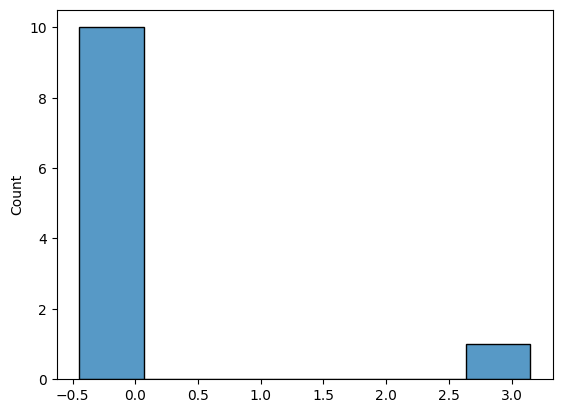

In [17]:
import seaborn as sns
sns.histplot(zs)

<Axes: >

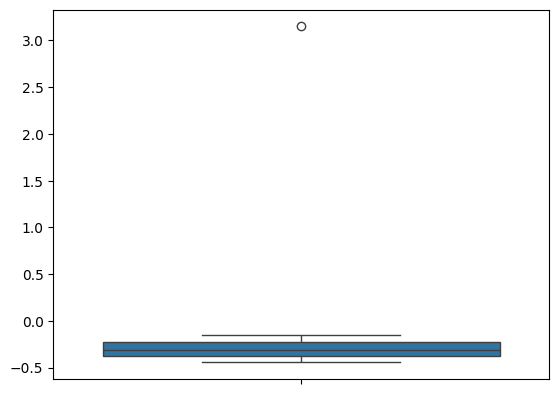

In [18]:
sns.boxplot(zs)

In [19]:
import pandas as pd

# Sales data (5 reps x 6 months)
data = {
    "Rep": ["A", "B", "C", "D", "E"],
    "Jan": [22, 18, 31, 25, 15],
    "Feb": [28, 19, 30, 23, 17],
    "Mar": [25, 21, 28, 24, 16],
    "Apr": [27, 20, 33, 22, 18],
    "May": [30, 22, 35, 25, 17],
    "Jun": [26, 19, 32, 26, 19]
}

df = pd.DataFrame(data)
print(df)


  Rep  Jan  Feb  Mar  Apr  May  Jun
0   A   22   28   25   27   30   26
1   B   18   19   21   20   22   19
2   C   31   30   28   33   35   32
3   D   25   23   24   22   25   26
4   E   15   17   16   18   17   19


### Coeff of Variation

In [34]:
df["Mean"] = df.iloc[:, 1:].mean(axis=1)
df["SD"] = df.iloc[:, 1:].std(axis=1)
df["CV (%)"] = (df["SD"] / df["Mean"]) * 100
df

,Rep,Jan,Feb,Mar,Apr,May,Jun,Mean,SD,CV (%)
0,A,22,28,25,27,30,26,26.333333,2.494438,9.472550
1,B,18,19,21,20,22,19,19.833333,1.343710,6.775007
2,C,31,30,28,33,35,32,31.500000,2.217356,7.039225
3,D,25,23,24,22,25,26,24.166667,1.343710,5.560178
4,E,15,17,16,18,17,19,17.000000,1.290994,7.594085


In [25]:
z_df = df.set_index("Rep").apply(stats.zscore)
z_df = z_df.reset_index()
z_df.round(2)

,Rep,Jan,Feb,Mar,Apr,May,Jun
0,A,-0.04,0.92,0.54,0.56,0.67,0.32
1,B,-0.75,-0.88,-0.44,-0.74,-0.61,-1.10
2,C,1.58,1.32,1.28,1.67,1.47,1.54
3,D,0.50,-0.08,0.29,-0.37,-0.13,0.32
4,E,-1.29,-1.28,-1.67,-1.11,-1.41,-1.10


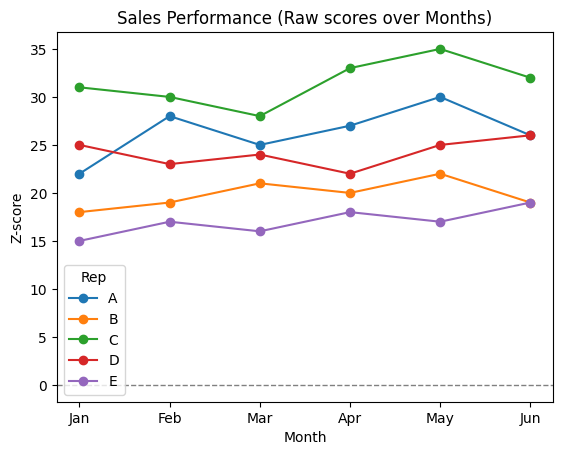

In [33]:
for rep in df["Rep"]:
    plt.plot(df.columns[1:], df.loc[df["Rep"] == rep].values[0][1:], marker='o', label=rep)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title("Sales Performance (Raw scores over Months)")
plt.xlabel("Month")
plt.ylabel("Z-score")
plt.legend(title="Rep")
plt.show()


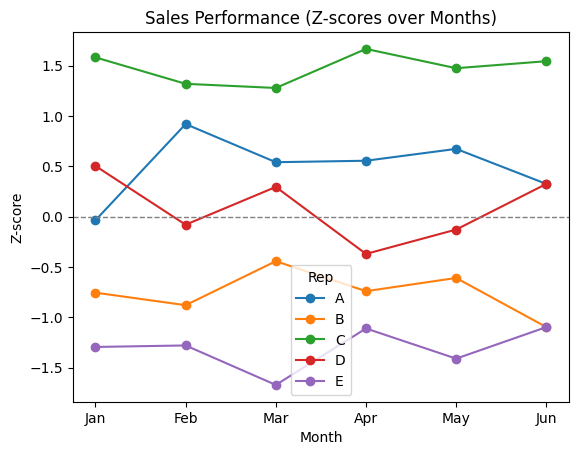

In [26]:
import matplotlib.pyplot as plt

for rep in z_df["Rep"]:
    plt.plot(z_df.columns[1:], z_df.loc[z_df["Rep"] == rep].values[0][1:], marker='o', label=rep)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title("Sales Performance (Z-scores over Months)")
plt.xlabel("Month")
plt.ylabel("Z-score")
plt.legend(title="Rep")
plt.show()


### mean, sd, mad, iqr comparison

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Normal-like data (roughly symmetric)
np.random.seed(42)
data_normal = np.random.normal(50, 10, 100)

# Skewed data with outliers
data_skewed = np.append(np.random.exponential(20, 100), [200, 250, 300])

datasets = {
    "Normal Distribution": data_normal,
    "Skewed / Outlier Data": data_skewed
}


In [36]:
def summarize_spread(data):
    mean = np.mean(data)
    sd = np.std(data)
    mad = np.mean(np.abs(data - mean))
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    return mean, sd, mad, iqr


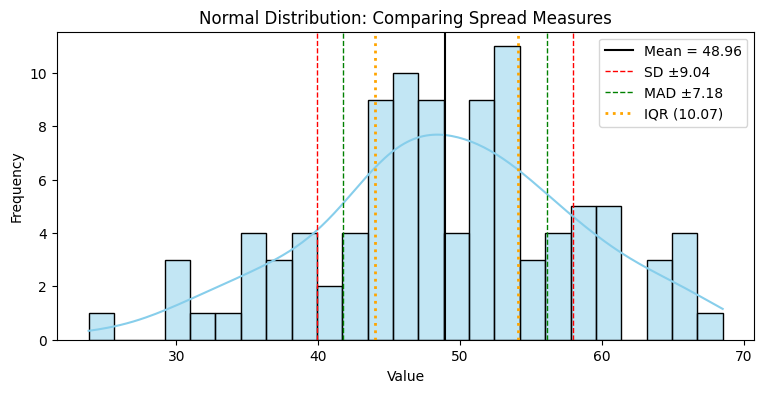

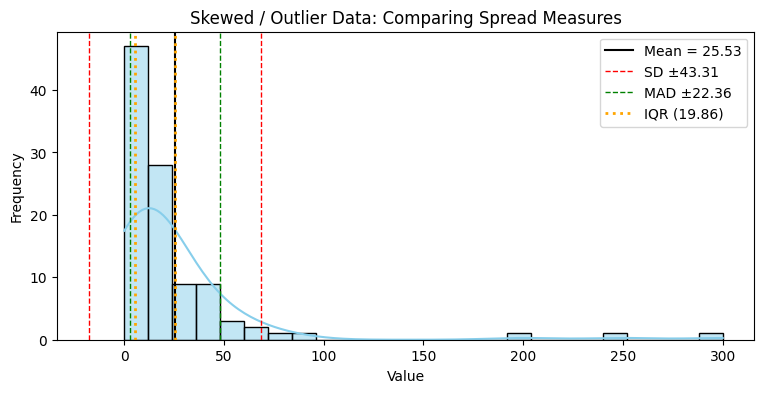

In [37]:
for name, data in datasets.items():
    mean, sd, mad, iqr = summarize_spread(data)

    plt.figure(figsize=(9, 4))
    sns.histplot(data, bins=25, kde=True, color="skyblue")
    
    # Mark mean
    plt.axvline(mean, color="black", linestyle="-", linewidth=1.5, label=f"Mean = {mean:.2f}")
    
    # Mark SD range
    plt.axvline(mean - sd, color="red", linestyle="--", linewidth=1, label=f"SD ±{sd:.2f}")
    plt.axvline(mean + sd, color="red", linestyle="--", linewidth=1)
    
    # Mark MAD range
    plt.axvline(mean - mad, color="green", linestyle="--", linewidth=1, label=f"MAD ±{mad:.2f}")
    plt.axvline(mean + mad, color="green", linestyle="--", linewidth=1)
    
    # Mark IQR (based on quartiles)
    plt.axvline(np.percentile(data, 25), color="orange", linestyle=":", linewidth=2, label=f"IQR ({iqr:.2f})")
    plt.axvline(np.percentile(data, 75), color="orange", linestyle=":", linewidth=2)

    plt.title(f"{name}: Comparing Spread Measures")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()


In [4]:
df = pd.read_csv("C:\\git\\ML-hands-on-notebooks\\data\\titanic-train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: ylabel='Frequency'>

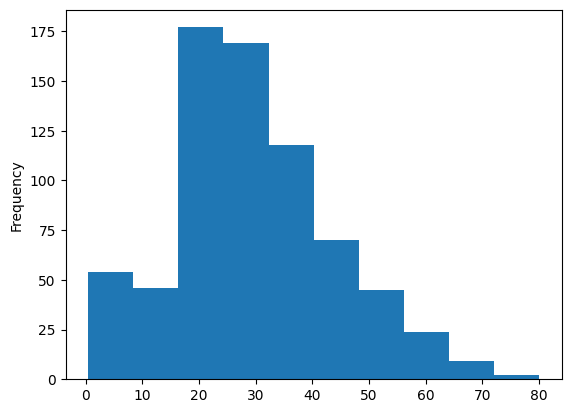

In [11]:
df["Age"].plot(kind='hist')

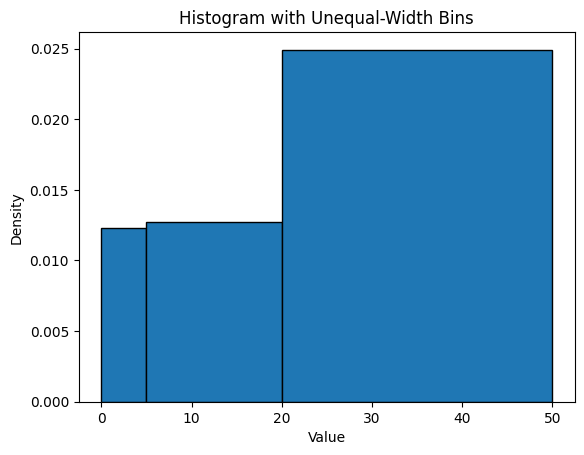

In [25]:
# Unequal-width bins
bins = [0, 5, 20, 50]

plt.hist(df["Age"], bins=bins, edgecolor='black', density=True)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Histogram with Unequal-Width Bins")
plt.show()

In [20]:
df["Age"].describe(percentiles=[0.9,0.99])

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
50%       28.000000
90%       50.000000
99%       65.870000
max       80.000000
Name: Age, dtype: float64

In [21]:
df["Age"].quantile(.99)

np.float64(65.87)

<Axes: ylabel='Age'>

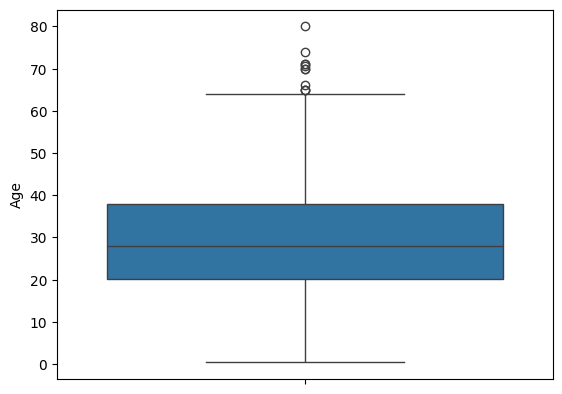

In [22]:
sns.boxplot(df["Age"])

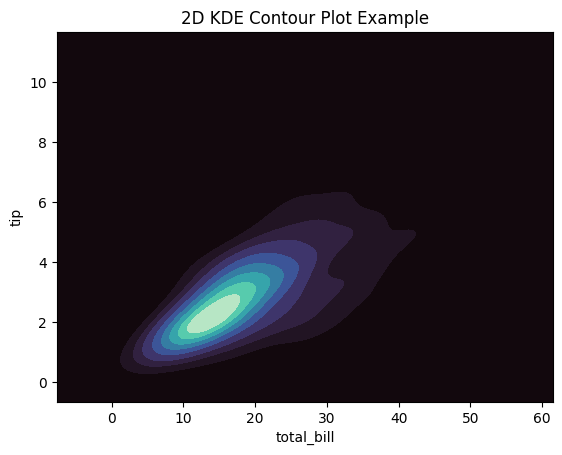

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: joint distribution of height and weight
tips = sns.load_dataset("tips")

sns.kdeplot(
    data=tips,
    x="total_bill",
    y="tip",
    fill=True,   # fill the contours
    cmap="mako", # color map
    #levels=[0.5, 0.8, 0.9],  # probability mass contours
    thresh=0
)
plt.title("2D KDE Contour Plot Example")
plt.show()
